In [1]:
import os
import urllib.request
from urllib.error import HTTPError
from tokenizers import ByteLevelBPETokenizer
import time
import numpy as np
import multiprocessing as mp
import tensorflow as tf
import matplotlib.pyplot as plt

2026-04-26 17:47:13.206620: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777225633.431754      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777225633.497997      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777225634.013796      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777225634.013879      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777225634.013883      16 computation_placer.cc:177] computation placer alr

# Data exploration

We will look into the distribution of the number of tokens.
As a prerequisite, we need to:
  - download the dataset
  - Build the BPE tokenizer

Let start with downloading the dataset.

In [2]:
!rm data.py configs.py tokenizer.py
!rm -rf tokenizer_32_000_vocab_size_model

!mkdir de_tokenizer_32_000_vocab_size_model

rm: cannot remove 'data.py': No such file or directory
rm: cannot remove 'configs.py': No such file or directory
rm: cannot remove 'tokenizer.py': No such file or directory


In [3]:
base_url = "https://raw.githubusercontent.com/MiguelSteph/transformer-from-scratch/version2/"
def download_file_from_github(file_path: str, file_name: str):
    if not os.path.isfile(file_name):
        file_url = base_url + file_path
        print(f"Downloading {file_url}...")
        try:
            urllib.request.urlretrieve(file_url, file_name)
        except HTTPError as e:
            print("Something went wrong. Please try to download the file directly from the GitHub repository:\n", e)

file_paths = [
    'configs/configs.py',
    'data/tokenizer.py',
    'data/data.py',
    'data/tokenizer_32_000_vocab_size_model/merges.txt',
    'data/tokenizer_32_000_vocab_size_model/vocab.json',
]
file_names = [
    'configs.py',
    'tokenizer.py',
    'data.py',
    'tokenizer_32_000_vocab_size_model/merges.txt',
    'tokenizer_32_000_vocab_size_model/vocab.json',
]

for file_path, file_name in zip(file_paths, file_names): 
    download_file_from_github(file_path, file_name)

Something went wrong. Please try to download the file directly from the GitHub repository:
 HTTP Error 404: Not Found
Something went wrong. Please try to download the file directly from the GitHub repository:
 HTTP Error 404: Not Found


In [4]:
from configs import get_configs
from data import build_and_save_tokenizer_models, download_and_get_raw_datasets

config = get_configs()

# Build and save BPE tokenizer model

This is one time script that will create the BPE tokenizer model and dave it.

In [5]:
build_and_save_tokenizer_models()

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/wmt_translate/de-en/incomplete.4XB0M4_1.0.0/wmt_translate-test.tfrecord*..…

Dataset wmt_translate downloaded and prepared to /root/tensorflow_datasets/wmt_translate/de-en/1.0.0. Subsequent calls will reuse this data.


2026-04-26 17:54:30.134962: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


--- Starting Tokenizer ---



--- Tokenizer built and saved ---


# Data exploration

In [6]:
train_ds, validation_ds, test_ds = download_and_get_raw_datasets()

train_de_data = train_ds.map(lambda x: x["de"], num_parallel_calls=tf.data.AUTOTUNE)
train_en_data = train_ds.map(lambda x: x["en"], num_parallel_calls=tf.data.AUTOTUNE)

val_de_data = validation_ds.map(lambda x: x["de"], num_parallel_calls=tf.data.AUTOTUNE)
val_en_data = validation_ds.map(lambda x: x["en"], num_parallel_calls=tf.data.AUTOTUNE)

test_de_data = test_ds.map(lambda x: x["de"], num_parallel_calls=tf.data.AUTOTUNE)
test_en_data = test_ds.map(lambda x: x["en"], num_parallel_calls=tf.data.AUTOTUNE)

de_tokenizer = ByteLevelBPETokenizer(config.data.de_tokenizer_model_path + '/vocab.json',
                                     config.data.de_tokenizer_model_path + '/merges.txt')
de_tokenizer.add_special_tokens(list(config.data.special_tokens))
en_tokenizer = ByteLevelBPETokenizer(config.data.en_tokenizer_model_path + '/vocab.json',
                                     config.data.en_tokenizer_model_path + '/merges.txt')
en_tokenizer.add_special_tokens(list(config.data.special_tokens))

def get_en_tokens_length(input: np.ndarray) -> list[int]:
    lengths = []
    for sample in input:
        lengths.append(len(en_tokenizer.encode(sample.decode('utf-8')).ids))
    return lengths

def get_de_tokens_length(input: np.ndarray) -> list[int]:
    lengths = []
    for sample in input:
        lengths.append(len(de_tokenizer.encode(sample.decode('utf-8')).ids))
    return lengths

start_time = time.time()
cpu_count = os.cpu_count()
with mp.Pool(cpu_count) as pool:
    train_de_tokens_lengths = []
    for tokens_length in pool.imap(get_de_tokens_length, train_de_data.batch(100).as_numpy_iterator(), chunksize=16):
        train_de_tokens_lengths.extend(tokens_length)

with mp.Pool(cpu_count) as pool:
    val_de_tokens_lengths = []
    for tokens_length in pool.imap(get_de_tokens_length, val_de_data.batch(100).as_numpy_iterator(), chunksize=16):
        val_de_tokens_lengths.extend(tokens_length)

with mp.Pool(cpu_count) as pool:
    test_de_tokens_lengths = []
    for tokens_length in pool.imap(get_de_tokens_length, test_de_data.batch(100).as_numpy_iterator(), chunksize=16):
        test_de_tokens_lengths.extend(tokens_length)

print(f"German Token length counting took {time.time() - start_time} seconds")


start_time = time.time()
cpu_count = os.cpu_count()
with mp.Pool(cpu_count) as pool:
    train_en_tokens_lengths = []
    for tokens_length in pool.imap(get_en_tokens_length, train_en_data.batch(100).as_numpy_iterator(), chunksize=16):
        train_en_tokens_lengths.extend(tokens_length)

with mp.Pool(cpu_count) as pool:
    val_en_tokens_lengths = []
    for tokens_length in pool.imap(get_en_tokens_length, val_en_data.batch(100).as_numpy_iterator(), chunksize=16):
        val_en_tokens_lengths.extend(tokens_length)

with mp.Pool(cpu_count) as pool:
    test_en_tokens_lengths = []
    for tokens_length in pool.imap(get_en_tokens_length, test_en_data.batch(100).as_numpy_iterator(), chunksize=16):
        test_en_tokens_lengths.extend(tokens_length)

print(f"English Token length counting took {time.time() - start_time}")

German Token length counting took 364.41814637184143 seconds
English Token length counting took 345.31536960601807


======TRAINING======
German Max token length:  10084
English Max token length: 15126
German Min token length:  1
English Min token length: 1

======VALIDATION======
German Max token length:  219
English Max token length: 199
German Min token length:  1
English Min token length: 1

======TEST======
German Max token length:  133
English Max token length: 123
German Min token length:  2
English Min token length: 2



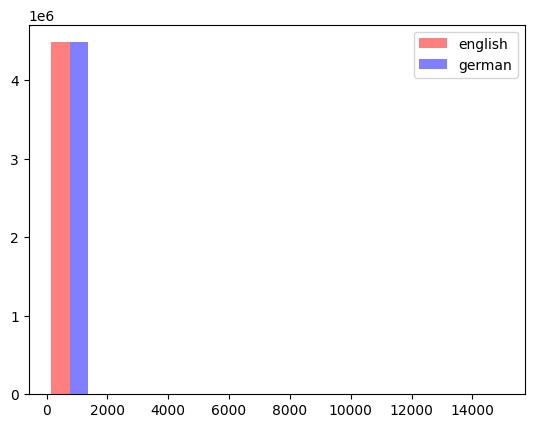

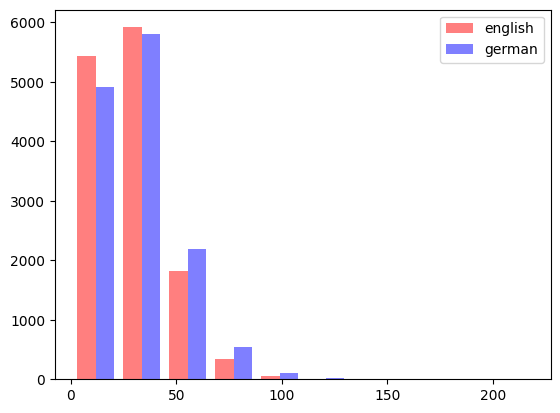

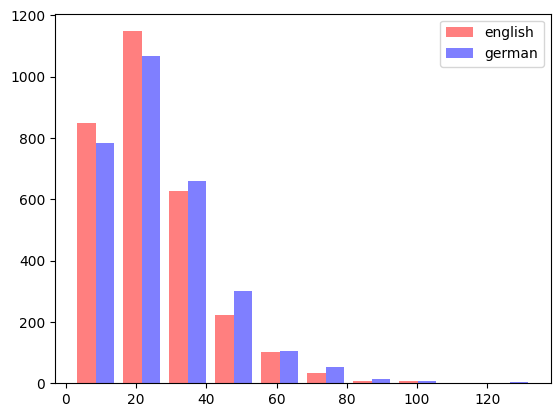

In [7]:
print("======TRAINING======")
print(f"German Max token length:  {max(train_de_tokens_lengths)}")
print(f"English Max token length: {max(train_en_tokens_lengths)}")
print(f"German Min token length:  {min(train_de_tokens_lengths)}")
print(f"English Min token length: {min(train_en_tokens_lengths)}")
print()

print("======VALIDATION======")
print(f"German Max token length:  {max(val_de_tokens_lengths)}")
print(f"English Max token length: {max(val_en_tokens_lengths)}")
print(f"German Min token length:  {min(val_de_tokens_lengths)}")
print(f"English Min token length: {min(val_en_tokens_lengths)}")
print()

print("======TEST======")
print(f"German Max token length:  {max(test_de_tokens_lengths)}")
print(f"English Max token length: {max(test_en_tokens_lengths)}")
print(f"German Min token length:  {min(test_de_tokens_lengths)}")
print(f"English Min token length: {min(test_en_tokens_lengths)}")
print()


plt.hist([train_en_tokens_lengths, train_de_tokens_lengths], color=['r', 'b'], label=['english', 'german'], alpha=0.5)
plt.legend()
plt.show()

plt.hist([val_en_tokens_lengths, val_de_tokens_lengths], color=['r', 'b'], label=['english', 'german'], alpha=0.5)
plt.legend()
plt.show()

plt.hist([test_en_tokens_lengths, test_de_tokens_lengths], color=['r', 'b'], label=['english', 'german'], alpha=0.5)
plt.legend()
plt.show()

In [8]:
def explore_for_max_tokens(max_tokens):
    train_de_out_of_range_samples = sum(item > max_tokens for item in train_de_tokens_lengths)
    train_en_out_of_range_samples = sum(item > max_tokens for item in train_en_tokens_lengths)

    val_de_out_of_range_samples = sum(item > max_tokens for item in val_de_tokens_lengths)
    val_en_out_of_range_samples = sum(item > max_tokens for item in val_en_tokens_lengths)

    test_de_out_of_range_samples = sum(item > max_tokens for item in test_de_tokens_lengths)
    test_en_out_of_range_samples = sum(item > max_tokens for item in test_en_tokens_lengths)

    print(f"=======TRAINING WITH MAX_SEQ_LENGTH={max_tokens}=======")
    print(f"Out of range German samples: {train_de_out_of_range_samples}")
    print(f"Out of range English samples: {train_en_out_of_range_samples}")
    print()

    print(f"=======VALIDATION WITH MAX_SEQ_LENGTH={max_tokens}=======")
    print(f"Out of range German samples: {val_de_out_of_range_samples}")
    print(f"Out of range English samples: {val_en_out_of_range_samples}")
    print()

    print(f"=======TEST WITH MAX_SEQ_LENGTH={max_tokens}=======")
    print(f"Out of range German samples: {test_de_out_of_range_samples}")
    print(f"Out of range English samples: {test_en_out_of_range_samples}")
    print()
    
    train_de_reduced_tokens_lengths = [token_len for token_len in train_de_tokens_lengths if token_len <= max_tokens]
    train_en_reduced_tokens_lengths = [token_len for token_len in train_en_tokens_lengths if token_len <= max_tokens]

    val_de_reduced_tokens_lengths = [token_len for token_len in val_de_tokens_lengths if token_len <= max_tokens]
    val_en_reduced_tokens_lengths = [token_len for token_len in val_en_tokens_lengths if token_len <= max_tokens]

    test_de_reduced_tokens_lengths = [token_len for token_len in test_de_tokens_lengths if token_len <= max_tokens]
    test_en_reduced_tokens_lengths = [token_len for token_len in test_en_tokens_lengths if token_len <= max_tokens]
    
    plt.hist([train_en_reduced_tokens_lengths, train_de_reduced_tokens_lengths], color=['r', 'b'], label=[f"english - train", f"german - train"], alpha=0.5)
    plt.legend()
    plt.show()

    plt.hist([val_en_reduced_tokens_lengths, val_de_reduced_tokens_lengths], color=['r', 'b'], label=[f"english - validation", f"german - validation"], alpha=0.5)
    plt.legend()
    plt.show()

    plt.hist([test_en_reduced_tokens_lengths, test_de_reduced_tokens_lengths], color=['r', 'b'], label=[f"english - test", f"german - test"], alpha=0.5)
    plt.legend()
    plt.show()

=======TRAINING WITH MAX_SEQ_LENGTH=80=======
Out of range German samples: 86865
Out of range English samples: 77871

=======VALIDATION WITH MAX_SEQ_LENGTH=80=======
Out of range German samples: 247
Out of range English samples: 132

=======TEST WITH MAX_SEQ_LENGTH=80=======
Out of range German samples: 30
Out of range English samples: 15



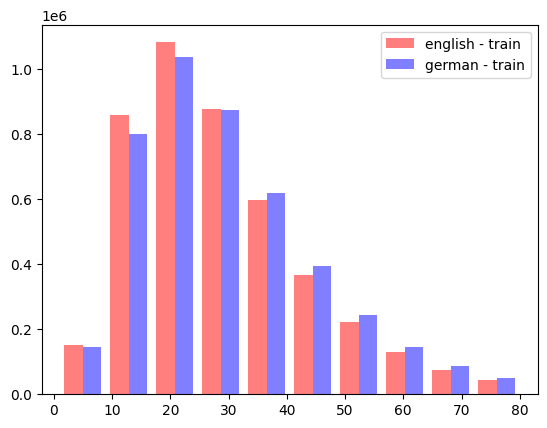

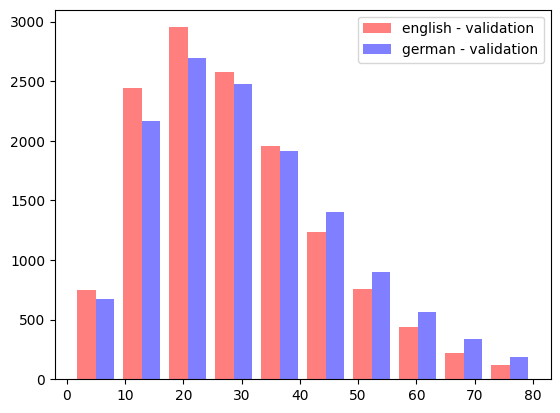

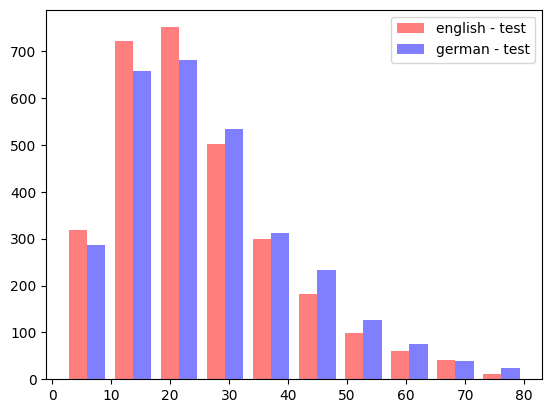

In [9]:
explore_for_max_tokens(max_tokens = 80)

=======TRAINING WITH MAX_SEQ_LENGTH=100=======
Out of range German samples: 30675
Out of range English samples: 27579

=======VALIDATION WITH MAX_SEQ_LENGTH=100=======
Out of range German samples: 52
Out of range English samples: 27

=======TEST WITH MAX_SEQ_LENGTH=100=======
Out of range German samples: 10
Out of range English samples: 5



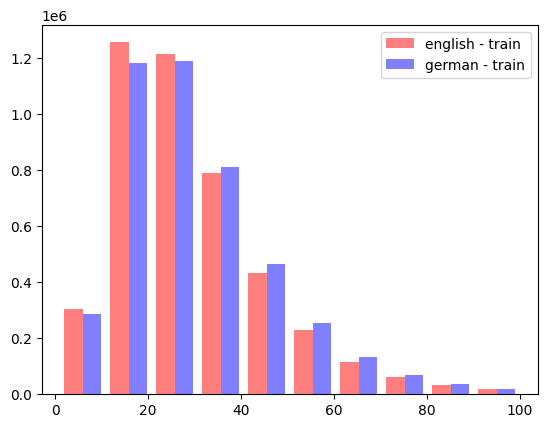

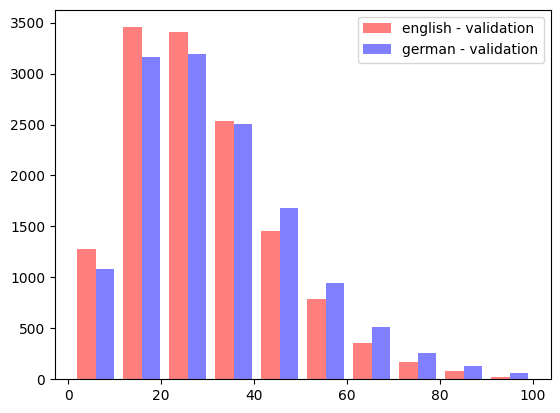

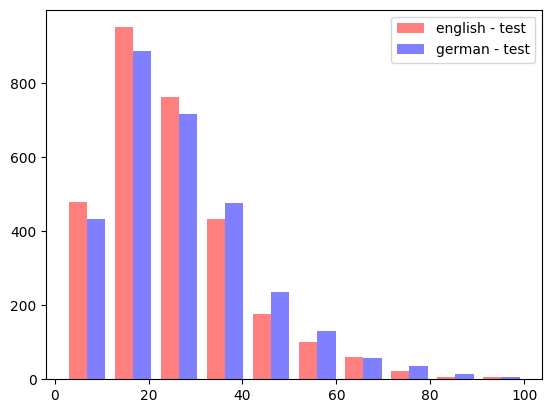

In [10]:
explore_for_max_tokens(max_tokens = 100)

=======TRAINING WITH MAX_SEQ_LENGTH=120=======
Out of range German samples: 13063
Out of range English samples: 11812

=======VALIDATION WITH MAX_SEQ_LENGTH=120=======
Out of range German samples: 11
Out of range English samples: 6

=======TEST WITH MAX_SEQ_LENGTH=120=======
Out of range German samples: 4
Out of range English samples: 1



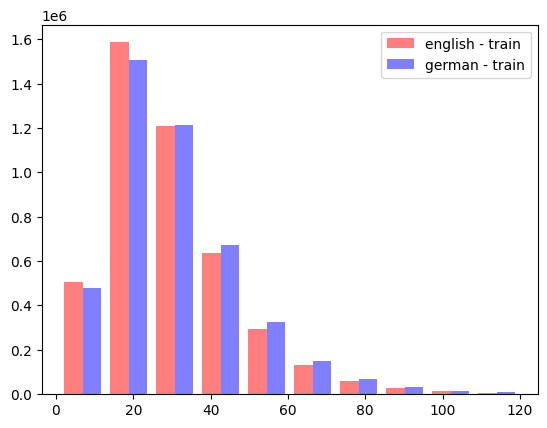

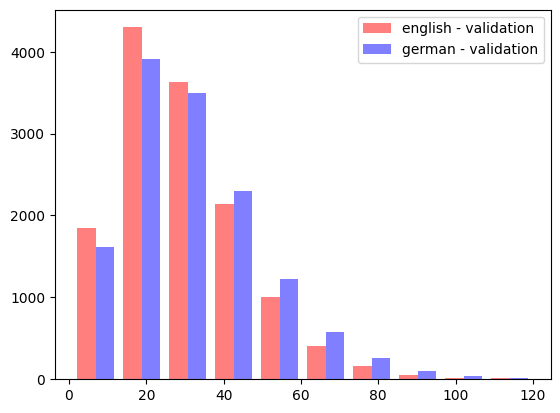

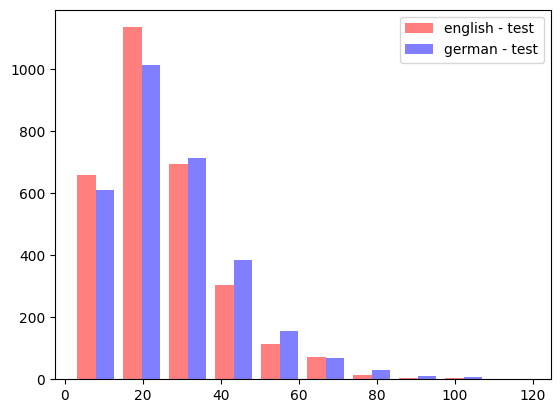

In [11]:
explore_for_max_tokens(max_tokens = 120)

=======TRAINING WITH MAX_SEQ_LENGTH=140=======
Out of range German samples: 6915
Out of range English samples: 6236

=======VALIDATION WITH MAX_SEQ_LENGTH=140=======
Out of range German samples: 3
Out of range English samples: 4

=======TEST WITH MAX_SEQ_LENGTH=140=======
Out of range German samples: 0
Out of range English samples: 0



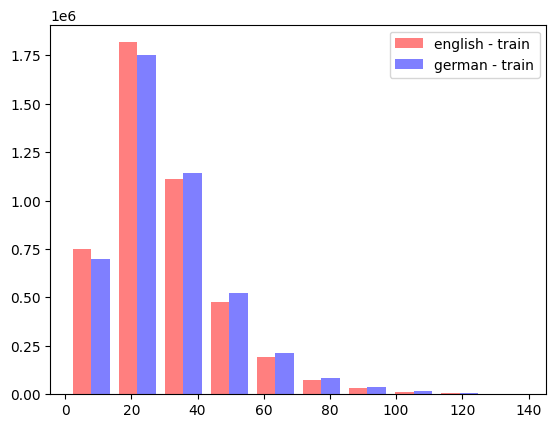

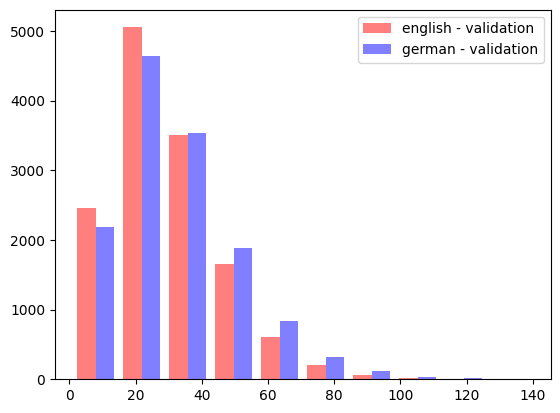

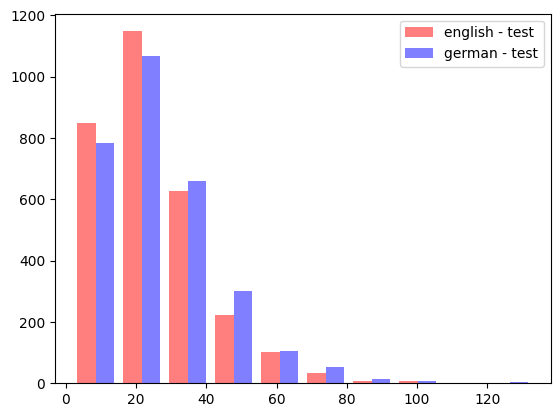

In [12]:
explore_for_max_tokens(max_tokens = 140)

=======TRAINING WITH MAX_SEQ_LENGTH=160=======
Out of range German samples: 4145
Out of range English samples: 3871

=======VALIDATION WITH MAX_SEQ_LENGTH=160=======
Out of range German samples: 2
Out of range English samples: 1

=======TEST WITH MAX_SEQ_LENGTH=160=======
Out of range German samples: 0
Out of range English samples: 0



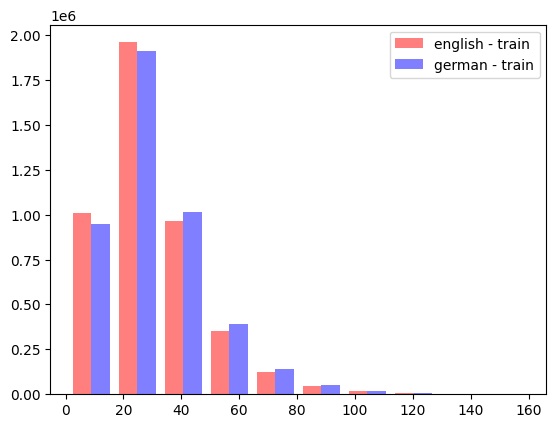

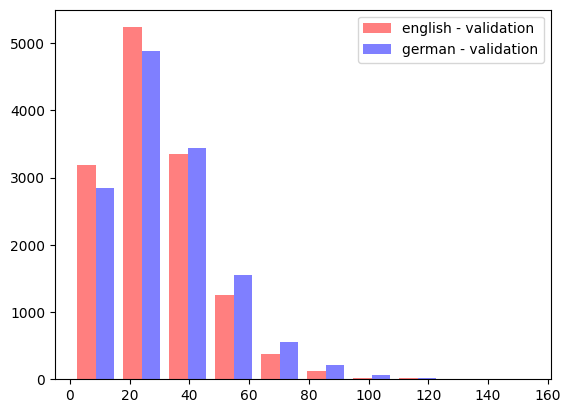

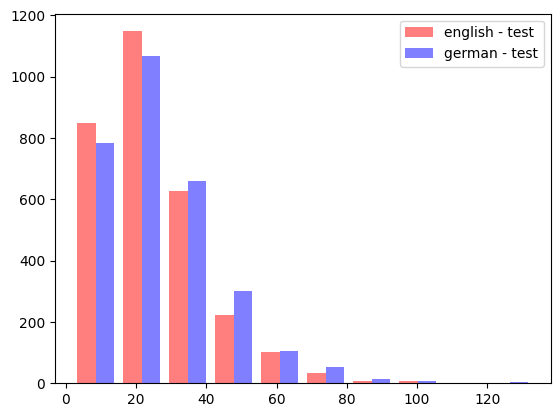

In [13]:
explore_for_max_tokens(max_tokens = 160)